# Noise Sensitivity Sweep: Darcy Continuous

- PDE: $-\nabla \cdot (a \nabla u) = 10$, continuous coefficient function
- Latent dimension: $d = 6$
- Sweep: SNR $\in \{50, 35, 25, 15\}$ dB and clean baseline

In [1]:
import sys, itertools, time
sys.path.insert(0, 'experiment_utils')
from _slurm import parse_slurm_task

PARAMETER_GRID = [
    {"seed": s, "snr": n}
    for s, n in itertools.product([42, 123, 7], [None, 50, 35, 25, 15])
]
_params, _task_id = parse_slurm_task(PARAMETER_GRID)

In [2]:
sys.path.insert(0, '..')
import load_this_before_everything_else

import jax
import jax.numpy as jnp
from jax import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import numpyro

from src.problems.darcy_continuous import DarcyContinuous, mollifier
from src.evaluation.metrics import rmse
from src.solver.config import InversionConfig, LossWeights, OptimizerConfig, SchedulerConfig

from experiment_utils import (
    crps_ensemble, compute_calibration, ci_width_95,
    plot_field_comparison, plot_calibration_overlay, plot_noise_sweep,
    plot_std_multi_panel, plot_sweep_summary_table, plot_trace,
    bootstrap_metric_ci, compute_error_std_correlation, chi2_ppc,
    tune_sigma, recommended_nuts_config,
    compute_prior_predictive, build_prior_result,
    load_problem, get_nf_mode, make_log_prior,
    make_gaussian_log_likelihood, make_numpyro_model,
    run_map_estimation, compute_sigma_from_map_residual,
    add_noise_snr_with_sigma,
    sample_unconditional_prior, decode_posterior_batched,
    run_mcmc, extract_mcmc_diagnostics,
    compute_standard_metrics,
    build_mcmc_result, save_experiment_result,
    load_cross_seed_results, cross_seed_metric_summary,
)

CHECKPOINT_PATH = Path('../runs/final_darcy_continuous/weights/best.pt')
TEST_DATA_PATH = '../data/darcy_continuous/smh_test_in.mat'
TEST_IDX = 0
N_OBS = 100
SNR_LEVELS = [50, 35, 25, 15]
NUM_WARMUP = 5000
NUM_SAMPLES = 2000
NUM_CHAINS = 4
CHAIN_METHOD = 'vectorized'

SEEDS = [42, 123, 7]
if _task_id is not None:
    SEEDS = [PARAMETER_GRID[_task_id]["seed"]]

print(f"JAX: {jax.__version__}, NumPyro: {numpyro.__version__}")
print(f"Devices: {jax.devices()}")

HIGH PRECISION MODE ACTIVATED!!!


JAX: 0.4.35, NumPyro: 0.19.0


Devices: [CudaDevice(id=0)]


## 1. Load Trained Model

In [3]:
problem = DarcyContinuous(seed=42, test_data_path=TEST_DATA_PATH)
params = load_problem(problem, CHECKPOINT_PATH)
beta_mode, d = get_nf_mode(problem, params)
log_prior_fn = make_log_prior(problem, params)

n_points = problem.get_n_points()
print(f"Latent dim: {d}")

Loading data...


  Test: a=(200, 841, 1), u=(200, 841, 1)
Setting up grids and test functions...


  int_grid: (45, 2), v: (45, 1)
Building models...


  Initialized enc: 116,038 params


  Initialized u: 102,006 params
  Initialized a: 102,006 params


E0614 13:05:35.448551      23 hlo_lexer.cc:443] Failed to parse int literal: 894515288310727292233


  Initialized nf: 10,280 params
Loading checkpoint: ../runs/final_darcy_continuous/weights/best.pt
  Loaded enc
  Loaded u
  Loaded a
  Loaded nf


Latent dim: 6


## 2. Inversion Config

In [4]:
inv_config = InversionConfig(
    epochs=200,
    loss_weights=LossWeights(pde=1.0, data=50.0),
    optimizer=OptimizerConfig(type='Adam', lr=0.01),
    scheduler=SchedulerConfig(type='StepLR', step_size=25, gamma=0.8),
)

## 3. Per-Seed Loop


######################################################################
# SEED = 42
######################################################################


x_obs: (1, 100, 2), u_obs_clean: (1, 100, 1)
a_true range: [0.102, 4.099]


Prior predictive: a_err=0.2783, CRPS=0.3352, cov95=0.9727


  Inversion grid: n_mesh_or_grid=7, n_grid=25


Loss weights: pde=1.0, data=50.0, target=u


...

sample: 100%|█████████▉| 1995/2000 [01:48<00:00, 23.07it/s]

sample: 100%|█████████▉| 1998/2000 [01:49<00:00, 21.94it/s]

sample: 100%|██████████| 2000/2000 [01:49<00:00, 18.32it/s]

MCMC warmup: 355.0s, sampling: 109.2s

                mean       std    median      5.0%     95.0%     n_eff     r_hat
   beta[0]      0.31      0.03      0.32      0.27      0.35    521.24      1.01
   beta[1]     -0.48      0.09     -0.47     -0.63     -0.33    679.62      1.00
   beta[2]      0.14      0.05      0.15      0.06      0.22    472.83      1.01
   beta[3]     -0.11      0.05     -0.11     -0.19     -0.02    580.75      1.00
   beta[4]     -0.43      0.07     -0.45     -0.54     -0.32    458.99      1.01
   beta[5]     -0.27      0.05     -0.27     -0.35     -0.20   1353.59      1.00

Number of divergences: 28
ESS min=459.0, R-hat max=1.0077, divergences=28/8000, [PASS] All diagnostics within thresholds


  Chi2 PPC: chi2=1.04, p=1.0000 (df=100)
Saved structured result to: /workspace/experiments/results/structured/noise_sweep/darcy_continuous_2026-06-14T13-55-57_seed42.json

  Darcy Continuous — Noise Sensitivity
  Condition                  CRPS(a)    Coverage    CI Width   Sharpness   Rel.L2(a)     Diverg.     ESS min       R-hat    Flag
  ------------------------------------------------------------------------------------------------------------------------------
  Clean                     0.021220     99.88%     0.298827    0.077279    0.012421          28       459.0      1.0077    PASS



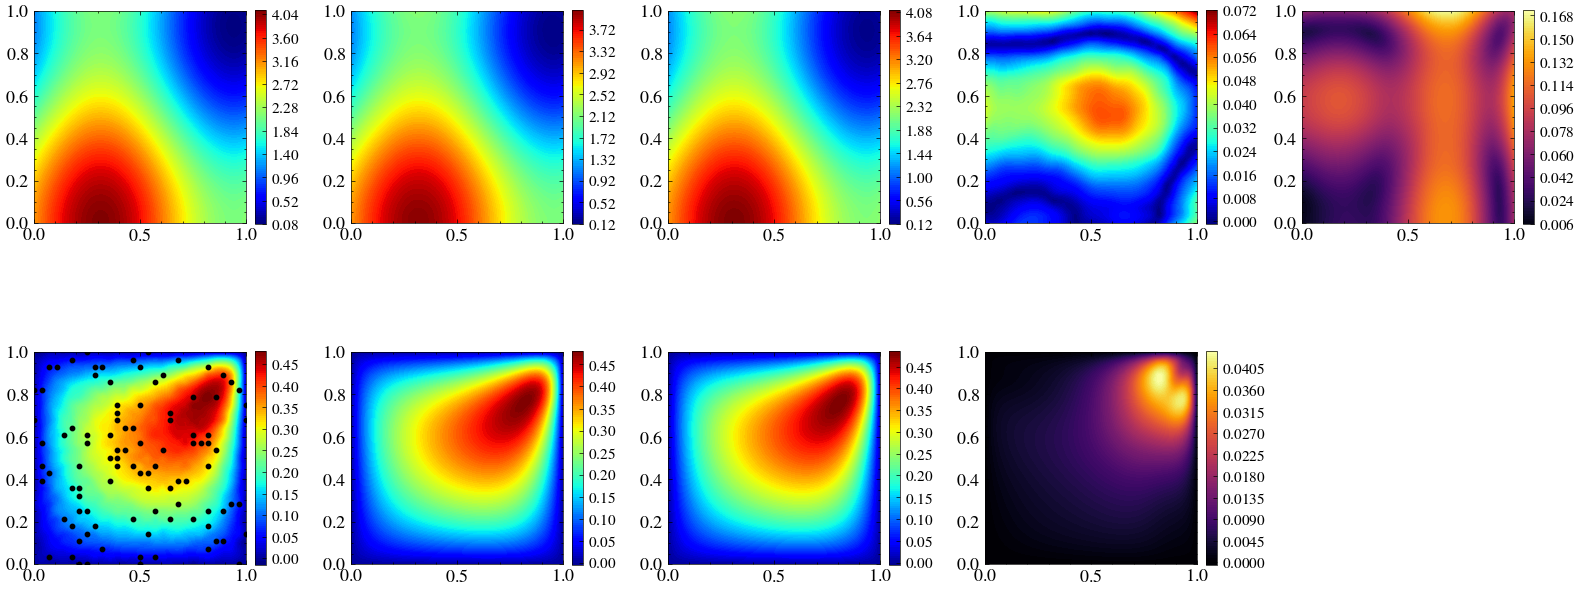


Bootstrap CIs on CRPS(a) at each condition:
         label      CRPS              95% CI


      SNR=35dB  0.02122  [0.02088, 0.02159]


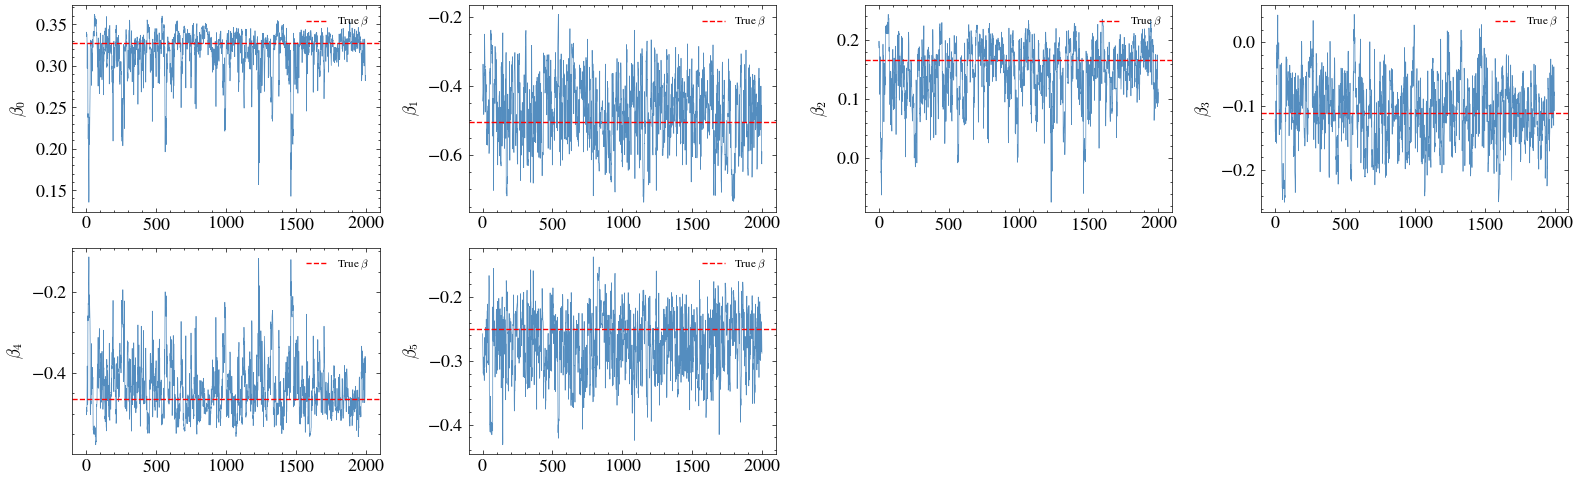

In [5]:
from results_schema import ExperimentResult
from datetime import datetime
from src.utils.PlotFigure import Plot

for SEED in SEEDS:
    _t_total_start = time.time()
    print(f"\n{'#'*70}\n# SEED = {SEED}\n{'#'*70}")

    FIGURE_DIR = Path(f'figures/noise_sweep_darcy_continuous/seed_{SEED}')
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)

    rng = random.PRNGKey(SEED)
    rng, key = random.split(rng)

    obs_indices = problem.sample_observation_indices(n_points, N_OBS, 'random', key)
    obs_data = problem.prepare_observations(sample_indices=[TEST_IDX], obs_indices=obs_indices)

    x_full = obs_data['x_full']
    x_obs = obs_data['x_obs']
    u_obs_clean = obs_data['u_obs']
    a_true = obs_data['a_true']
    u_true = obs_data['u_true']

    print(f"x_obs: {x_obs.shape}, u_obs_clean: {u_obs_clean.shape}")
    print(f"a_true range: [{float(a_true.min()):.3f}, {float(a_true.max()):.3f}]")

    # ### Prior Predictive Baseline
    a_true_np = np.array(a_true[0, :, 0])
    prior_a_samples, prior_metrics, rng = sample_unconditional_prior(
        problem, params, x_full, a_true_np, rng,
    )
    print(f"Prior predictive: a_err={prior_metrics['a_err']:.4f}, "
          f"CRPS={prior_metrics['crps_a']:.4f}, cov95={prior_metrics['coverage_95']:.4f}")

    # ### MAP Baseline
    map_result = run_map_estimation(problem, params, x_obs, u_obs_clean, x_full, inv_config, rng)
    beta_map = map_result['beta_map']
    a_map = map_result['a_map']
    _map_time_s = map_result['time_s']
    rng = map_result['rng']

    rmse_map_a = float(rmse(a_map, a_true[0]))
    print(f"MAP RMSE (a): {rmse_map_a:.6f}")

    sigma_map = compute_sigma_from_map_residual(problem, params, mollifier, beta_map, x_obs, u_obs_clean)
    print(f"sigma (MAP residual): {sigma_map:.6f}")

    # ### Sigma Tuning (closures must stay inline for tune_sigma)
    log_lik_clean = make_gaussian_log_likelihood(problem, params, mollifier, x_obs, u_obs_clean)
    numpyro_model_clean = make_numpyro_model(d, log_prior_fn, log_lik_clean)

    def _model_factory(sigma):
        def _model():
            numpyro_model_clean(sigma=sigma)
        return _model

    def _decode_fn(beta_samples):
        a_preds = []
        for i in range(len(beta_samples)):
            beta_i = beta_samples[i:i+1]
            preds = problem.predict_from_beta(params, jnp.array(beta_i), x_full)
            a_preds.append(np.array(preds['a_pred'][0, :, 0]))
        return np.stack(a_preds)

    rng, tune_key = jax.random.split(rng)
    sigma_tuned, _ = tune_sigma(
        model_fn_factory=_model_factory,
        beta_mode=beta_mode,
        sigma_candidates=[0.005, 0.01, 0.02, 0.04, 0.08, 0.15],
        rng_key=tune_key,
        decode_fn=_decode_fn,
        a_true=a_true_np,
        pilot_warmup=2000,
        pilot_samples=500,
        pilot_chains=2,
    )
    print(f"sigma (tuned): {sigma_tuned:.6f}")

    h = map_result['loss_history']
    Plot.show_loss(
        [h['total'], h['weighted_pde'], h['weighted_data']],
        ['Total', f'PDE (×{inv_config.loss_weights.pde})', f'Data (×{inv_config.loss_weights.data})'],
        save_path=str(FIGURE_DIR / 'map_loss_curves.png'),
    )

    # ### Run conditions
    def run_condition(snr_db, rng_key):
        rng_key, noise_key, mcmc_key = random.split(rng_key, 3)

        if snr_db is not None:
            u_obs_noisy, noise_sigma = add_noise_snr_with_sigma(u_obs_clean, snr_db, noise_key)
            label = f"SNR={snr_db}dB"
            print(f"\n{'='*60}\n  {label} (noise_sigma={noise_sigma:.6f})\n{'='*60}")
        else:
            u_obs_noisy = u_obs_clean
            noise_sigma = None
            label = "Clean"
            print(f"\n{'='*60}\n  {label}\n{'='*60}")

        sigma = max(noise_sigma if noise_sigma is not None else 0.0, sigma_tuned)

        log_lik_fn = make_gaussian_log_likelihood(problem, params, mollifier, x_obs, u_obs_noisy)
        numpyro_model = make_numpyro_model(d, log_prior_fn, log_lik_fn)

        nuts_cfg = recommended_nuts_config(d, sigma)
        print(f"  sigma={sigma} | target_accept_prob={nuts_cfg['target_accept_prob']}, "
              f"max_tree_depth={nuts_cfg['max_tree_depth']}")

        mcmc, timing = run_mcmc(
            numpyro_model, {"beta": beta_mode}, {"sigma": sigma}, mcmc_key,
            NUM_WARMUP, NUM_SAMPLES, NUM_CHAINS, CHAIN_METHOD, nuts_cfg,
        )
        mcmc.print_summary(exclude_deterministic=True)

        diag = extract_mcmc_diagnostics(mcmc, sample_name="beta", total_samples=NUM_CHAINS * NUM_SAMPLES)
        beta_samples = diag['samples']

        a_pred_all, u_pred_all = decode_posterior_batched(problem, params, beta_samples, x_full)

        metrics = compute_standard_metrics(a_pred_all, a_true_np)

        spearman_rho, spearman_p = compute_error_std_correlation(
            a_true_np, np.mean(a_pred_all, axis=0), np.std(a_pred_all, axis=0),
        )

        u_pred_at_obs = u_pred_all[:, np.array(obs_indices)]
        u_obs_np = np.array(u_obs_noisy[0, :, 0])
        chi2_stat, chi2_pval = chi2_ppc(u_obs_np, u_pred_at_obs, sigma)
        print(f"  Chi2 PPC: chi2={chi2_stat:.2f}, p={chi2_pval:.4f} (df={u_obs_np.shape[0]})")

        return {
            'label': label, 'snr_db': snr_db,
            'noise_sigma': noise_sigma, 'sigma': sigma,
            'beta_samples': np.array(beta_samples),
            'beta_by_chain': diag['by_chain'],
            'beta_for_trace': diag['by_chain'][0],
            'a_pred_all': a_pred_all, 'u_pred_all': u_pred_all,
            'a_mean': np.mean(a_pred_all, axis=0),
            'a_std': np.std(a_pred_all, axis=0),
            'u_mean': np.mean(u_pred_all, axis=0),
            'u_std': np.std(u_pred_all, axis=0),
            'ess_min': diag['ess_min'],
            'rhat_max': diag['rhat_max'],
            'rhat_mean': diag['rhat_mean'],
            'n_div': diag['n_div'],
            'reliability_flag': diag['flag'],
            'chi2_ppc': chi2_stat,
            'chi2_ppc_pvalue': chi2_pval,
            'spearman_rho_error_std': spearman_rho,
            'spearman_pvalue_error_std': spearman_p,
            'warmup_time_s': timing['warmup_time_s'],
            'sampling_time_s': timing['sampling_time_s'],
            'step_time_s': timing['step_time_s'],
            **metrics,
        }

    if _task_id is not None:
        _snr_iter = [PARAMETER_GRID[_task_id]["snr"]]
    else:
        _snr_iter = [None] + SNR_LEVELS

    all_results = []
    for snr_db in _snr_iter:
        rng, key = random.split(rng)
        res = run_condition(snr_db, key)
        if snr_db is None:
            res['map_a_err'] = rmse_map_a
        all_results.append(res)

    res_clean = next((r for r in all_results if r['snr_db'] is None), None)
    sweep_results = [r for r in all_results if r['snr_db'] is not None]

    def _to_mcmc_result(res):
        return build_mcmc_result(res, NUM_WARMUP, NUM_SAMPLES, NUM_CHAINS)

    experiment = ExperimentResult(
        experiment="noise_sweep",
        problem="darcy_continuous",
        experiment_type="sweep",
        sweep_var="snr_db",
        timestamp=datetime.now().strftime("%Y-%m-%dT%H:%M:%S"),
        seed=SEED,
        prior=build_prior_result(prior_metrics),
        baseline=_to_mcmc_result(res_clean) if res_clean is not None else None,
        sweep_conditions=[_to_mcmc_result(r) for r in sweep_results],
        map_time_s=_map_time_s,
        total_time_s=time.time() - _t_total_start,
    )

    out_path = save_experiment_result(experiment)
    print(f"Saved structured result to: {out_path}")


    # ### Plots
    x_np = np.array(x_full[0])
    a_map_np = np.array(a_map[:, 0])
    u_map_np = np.array(map_result['u_map'][:, 0])

    all_for_plot = ([res_clean] if res_clean is not None else []) + sweep_results
    all_labels = ['Clean'] + [f'SNR={s}dB' for s in SNR_LEVELS]
    plot_sweep_summary_table(all_for_plot, all_labels, title='Darcy Continuous — Noise Sensitivity')

    for res in all_for_plot:
        if res['noise_sigma'] is not None:
            key_viz = random.PRNGKey(int(res['snr_db']))
            u_display = np.array((u_true + random.normal(key_viz, u_true.shape) * res['noise_sigma'])[0, :, 0])
        else:
            u_display = np.array(u_true[0, :, 0])
        plot_field_comparison(
            x_np,
            a_true=a_true_np,
            a_map=a_map_np,
            a_mean=res['a_mean'],
            a_std=res['a_std'],
            grid_shape=(29, 29),
            u_true=u_display,
            u_map=u_map_np,
            u_mean=res['u_mean'],
            u_std=res['u_std'],
            obs_coords=np.array(x_obs[0]),
            save_path=FIGURE_DIR / f'field_comparison_{res["label"].replace("=", "").replace(" ", "_").lower()}.png',
        )

    if res_clean is not None:
        plot_noise_sweep(sweep_results, baseline=res_clean, save_path=FIGURE_DIR / 'noise_sweep.png')

        stds = [res_clean['a_std']] + [r['a_std'] for r in sweep_results]
        std_labels = ['Clean'] + [r['label'] for r in sweep_results]
        plot_std_multi_panel(
            x_np, stds, std_labels, grid_shape=(29, 29),
            suptitle='Posterior Std: Noise Sensitivity',
            save_path=FIGURE_DIR / 'std_multi_panel.png',
        )

        cal_list = [(res_clean['cal_levels'], res_clean['cal_empirical'], 'Clean')]
        for res in sweep_results:
            cal_list.append((res['cal_levels'], res['cal_empirical'], res['label']))
        plot_calibration_overlay(cal_list, save_path=FIGURE_DIR / 'calibration_overlay.png')

    def _crps_a(s, t): return float(np.mean(crps_ensemble(s, t)))

    rng_bs = np.random.default_rng(4)
    print("\nBootstrap CIs on CRPS(a) at each condition:")
    print(f"  {'label':>12s}  {'CRPS':>8s}  {'95% CI':>18s}")
    for res in all_for_plot:
        a_np = res['a_pred_all']
        ci = bootstrap_metric_ci(a_np, a_true_np, _crps_a, rng=rng_bs)
        print(f"  {res['label']:>12s}  {ci['estimate']:.5f}  [{ci['ci_lo']:.5f}, {ci['ci_hi']:.5f}]")

    beta_true = problem.models['enc'].apply({'params': params['enc']}, a_true)[0]
    beta_true_np = np.array(beta_true)
    for res in all_for_plot:
        plot_trace(
            res['beta_for_trace'], beta_true_np, num_warmup=0,
            save_path=FIGURE_DIR / f'trace_{res["label"].replace("=","").replace(" ","_").lower()}.png',
        )

## Cross-Seed Aggregation Summary

In [6]:
results = load_cross_seed_results("noise_sweep", "darcy_continuous")
SUMMARY_METRICS = ["a_err", "crps_a", "nll_a", "coverage_95", "ci_width", "mean_std", "ess_min", "rhat_max", "n_div"]

if len(results) > 1:
    print(f"Cross-Seed Sweep Summary ({len(results)} seeds: {[r.seed for r in results]})\n")

    if results[0].baseline is not None:
        print("=== Baseline (Clean) ===")
        print(f"{'Metric':<16s}  {'Mean':>10s}  {'Std':>10s}  {'Min':>10s}  {'Max':>10s}")
        print("-" * 62)
        for m in SUMMARY_METRICS:
            try:
                s = cross_seed_metric_summary(results, metric=m)
                if s["mean"] is not None:
                    print(f"{m:<16s}  {s['mean']:>10.4f}  {s['std']:>10.4f}  {s['min']:>10.4f}  {s['max']:>10.4f}")
            except (AttributeError, KeyError, TypeError):
                pass

    n_sweep = len(results[0].sweep_conditions) if results[0].sweep_conditions else 0
    for idx in range(n_sweep):
        label = results[0].sweep_conditions[idx].label or f"sweep[{idx}]"
        print(f"\n=== {label} ===")
        print(f"{'Metric':<16s}  {'Mean':>10s}  {'Std':>10s}  {'Min':>10s}  {'Max':>10s}")
        print("-" * 62)
        for m in SUMMARY_METRICS:
            vals = []
            for r in results:
                if r.sweep_conditions and idx < len(r.sweep_conditions):
                    v = getattr(r.sweep_conditions[idx], m, None)
                    if v is not None:
                        vals.append(float(v))
            if vals:
                arr = np.array(vals)
                std_val = float(np.std(arr, ddof=1)) if len(arr) > 1 else 0.0
                print(f"{m:<16s}  {float(np.mean(arr)):>10.4f}  {std_val:>10.4f}  {float(np.min(arr)):>10.4f}  {float(np.max(arr)):>10.4f}")
else:
    print(f"Only {len(results)} seed result(s) found - skipping cross-seed summary")

Cross-Seed Sweep Summary (35 seeds: [7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 42, 42, 42, 42, 42, 42, 42, 42, 42, 42, 42, 42, 42, 42, 123, 123, 123, 123, 123, 123, 123, 123, 123, 123, 123])

=== Baseline (Clean) ===
Metric                  Mean         Std         Min         Max
--------------------------------------------------------------
a_err                 0.0142      0.0068      0.0092      0.0250
crps_a                0.0222      0.0104      0.0131      0.0380
nll_a                -1.7634      0.5115     -2.2943     -1.0658
coverage_95           0.9988      0.0000      0.9988      0.9988
ci_width              0.3034      0.1687      0.1456      0.5527
mean_std              0.0779      0.0430      0.0378      0.1415
ess_min             403.8444    246.2099    106.6257    588.5849
rhat_max              1.0224      0.0188      1.0061      1.0448
n_div                48.1250     20.0459     29.0000     72.0000
